The dataset to be used in this session is a CSV file named telco_customer_churn.csv, which contains data on telecom customers churning and some of their key behaviors. It contains the following columns:

Features:
- customerID: Unique identifier of a customer.
- gender: Gender of customer.
- SeniorCitizen: Binary variable indicating if customer is senior citizen.
- Partner: Binary variable if customer has a partner.
- Dependents: Binary variable if customer has dependent.
- tenure: Number of weeks as a customer.
- PhoneService: Whether customer has phone service.
- MultipleLines: Whether customer has multiple lines.
- InternetService: What type of internet service customer has ("DSL", "Fiber optic", "No").
- OnlineSecurity: Whether customer has online security service.
- OnlineBackup: Whether customer has online backup service.
- DeviceProtection: Whether customer has device protection service.
- TechSupport: Whether customer has tech support service.
- StreamingTV: Whether customer has TV streaming service.
- StreamingMovies: Whether customer has movies streaming service.
- Contract: Customer Contract Type ('Month-to-month', 'One year', 'Two year').
- PaperlessBilling: Whether paperless billing is enabled.
- PaymentMethod: Payment method.
- MonthlyCharges: Amount of monthly charges in $.
- TotalCharges: Amount of total charges so far.

Target Variable:
Churn: Whether customer 'Stayed' or 'Churned'.

Data Understanding

In [2]:
# Dataset uploading from MYSQL server

import pandas as pd
import pymysql
import warnings

warnings.filterwarnings("ignore")

conn = pymysql.connect(host='localhost', user='root', password='6n6f7_X667', db='project')

df = pd.read_sql('SELECT * FROM project.telco_customer_churn', conn)

In [3]:
# Showing first 10 rows of the dataset

df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [4]:
# Dropping rows with missing TotalCharges

df.dropna(subset=['TotalCharges'], inplace=True)

In [5]:
# General information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [6]:
# Checking missing values

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
# Summarizing the statistics of the dataset

df_description = df.drop('SeniorCitizen', axis=1)
df_description.describe()


,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [8]:
# Identifying the data types

df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [9]:
# Depicting the shape of dataset

print(f"Number of columns: {df.shape[1]}")
print(f"Number of rows: {df.shape[0]}")


Number of columns: 21
Number of rows: 7032


In [10]:
# Introducing categorical and numerical values

categorical_cols = [
    'gender',
    'SeniorCitizen', # Its datatype might be integer, but as it is binary (0, 1) entity we can assume it as a categorical one.
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod',
    'Churn'
]

numerical_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

EDA

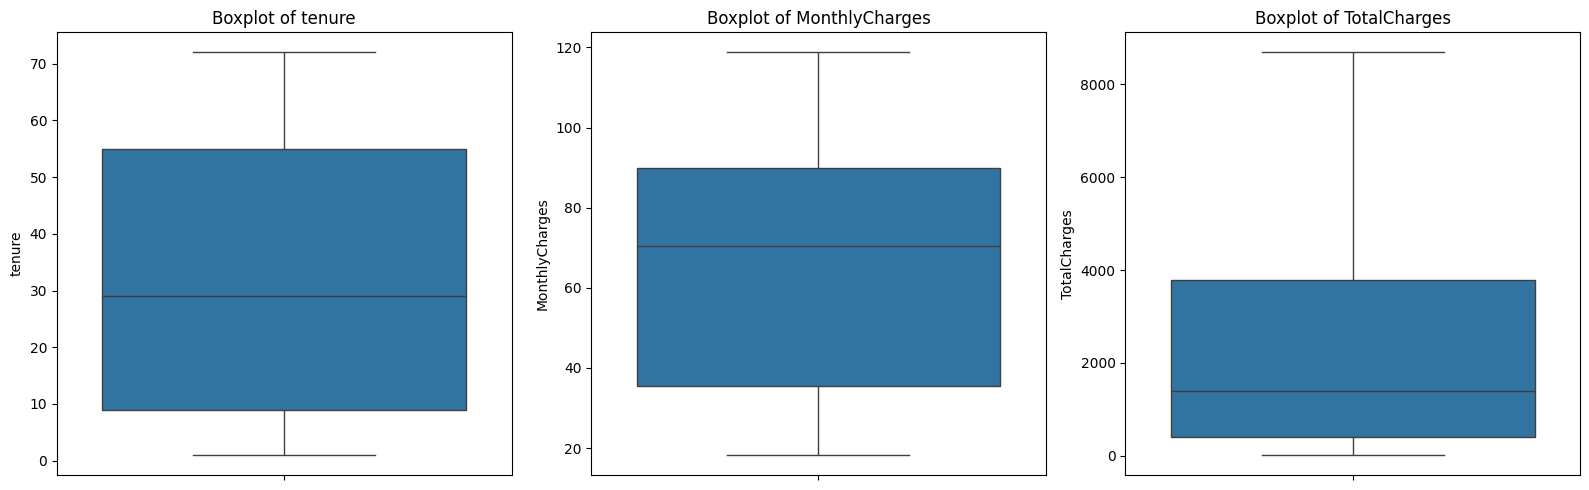

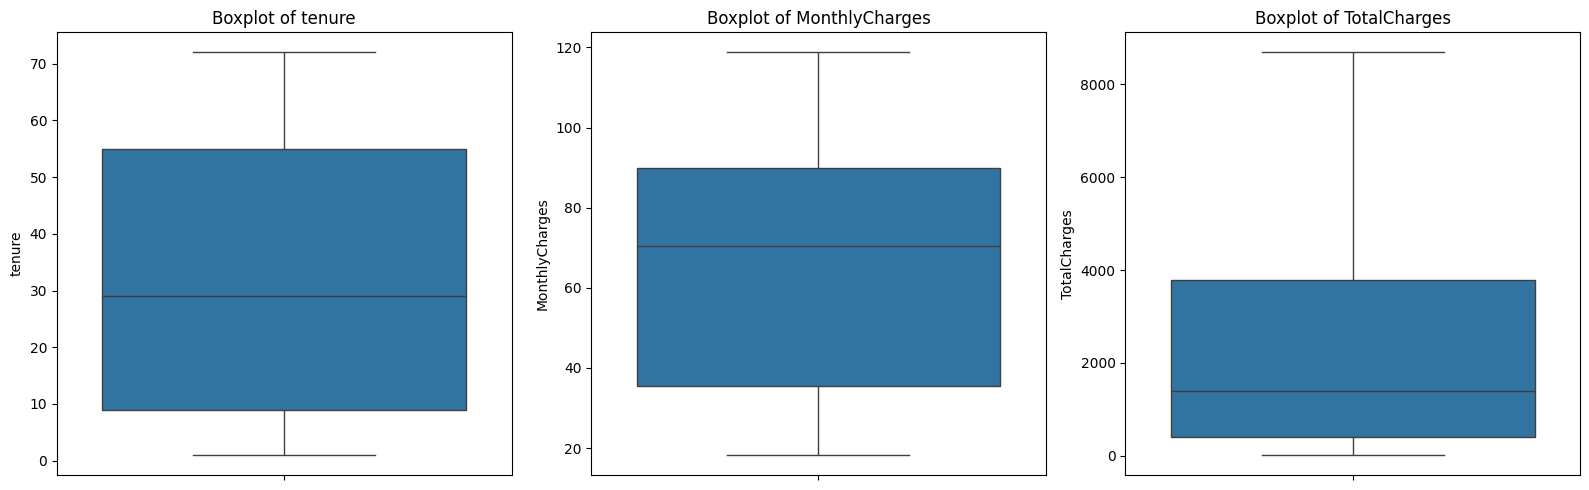

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplots for the numerical values (Outlier detection)

plt.figure(figsize=(16, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()


# Handling outliers

df_clean = df.copy()

def handle_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] > upper_bound, upper_bound, np.where(df[col] < lower_bound, lower_bound, df[col]))
    return df

for feature in numerical_cols:
    df_clean = handle_outliers(df_clean, feature)
    
# Boxplots after handling outliers

plt.figure(figsize=(16, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df_clean[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

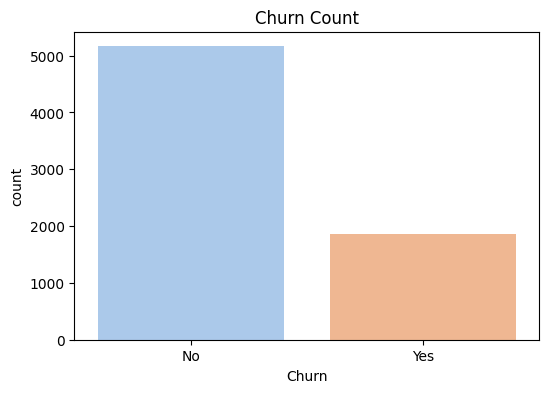

In [12]:
# Churn Count Plot

plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='pastel')
plt.title('Churn Count')
plt.show()

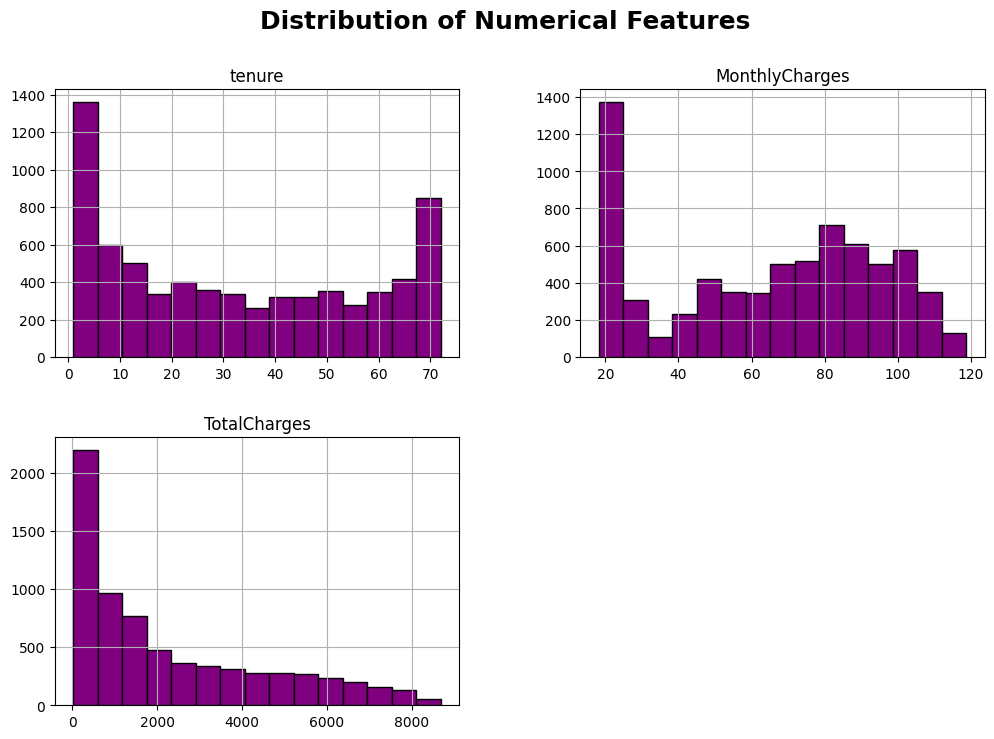

In [13]:
# Distribution of numerical columns

df[numerical_cols].hist(bins=15, figsize=(12, 8), color="purple", edgecolor="black")
plt.suptitle("Distribution of Numerical Features", fontsize=18, fontweight="bold")
plt.show()

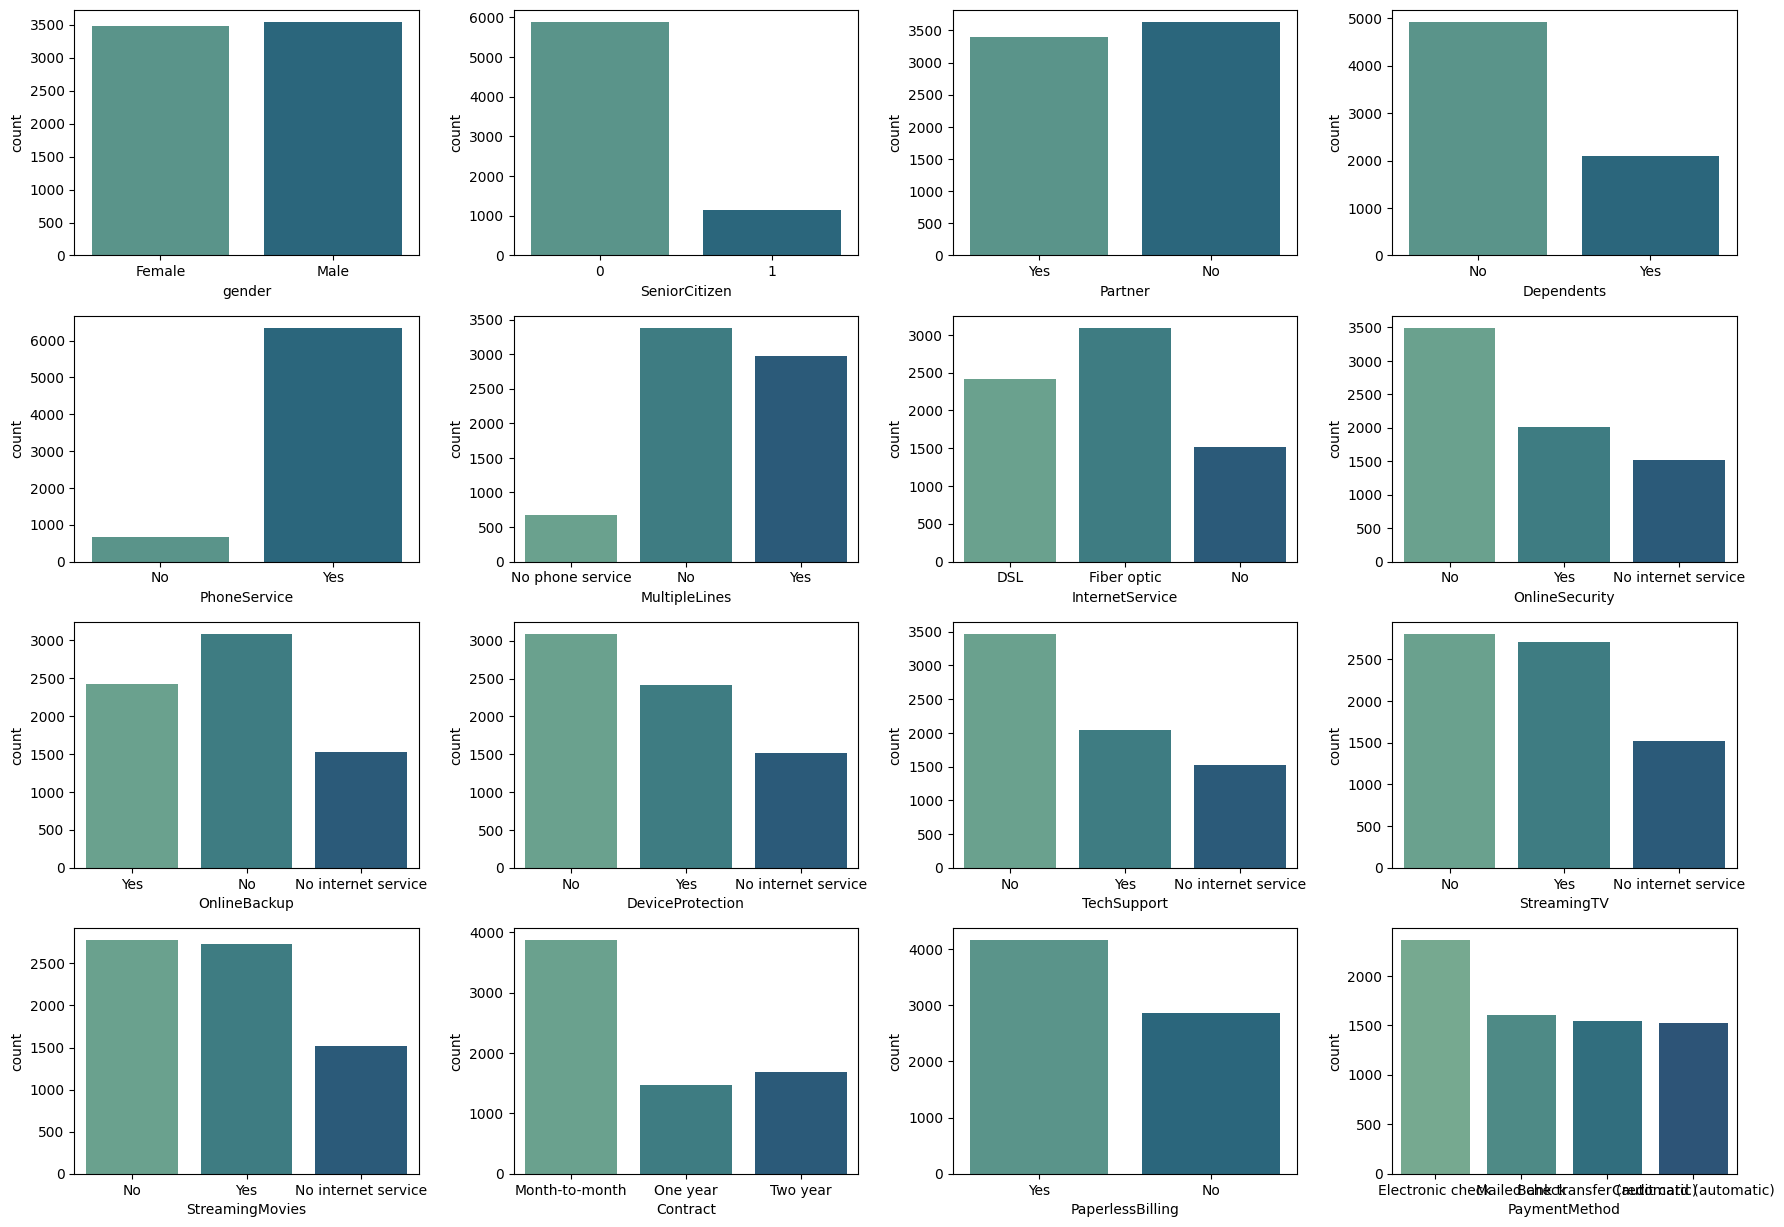

In [14]:
# Distribution of categorical values

categorical_cols_2 = [
    'gender',
    'SeniorCitizen', # Its datatype might be integer, but as it is binary (0, 1) entity we can assume it as a categorical one.
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod',
]
plt.figure(figsize=(18, 15))
for n, variable in enumerate(categorical_cols_2):
    ax = plt.subplot(5, 4, n + 1)
    g=sns.countplot(data=df, x=df[variable], ax=ax, palette='crest')
plt.tight_layout()
plt.show() 

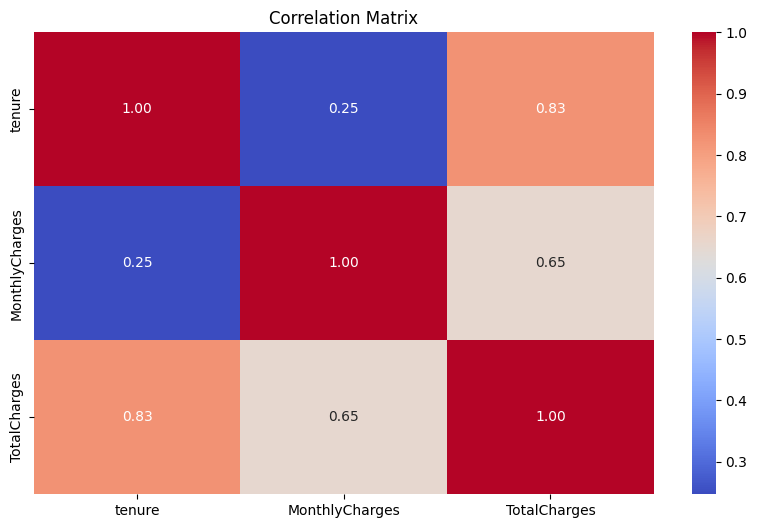

In [15]:
# Correlation Analysis

plt.figure(figsize=(10, 6))
correlation = df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

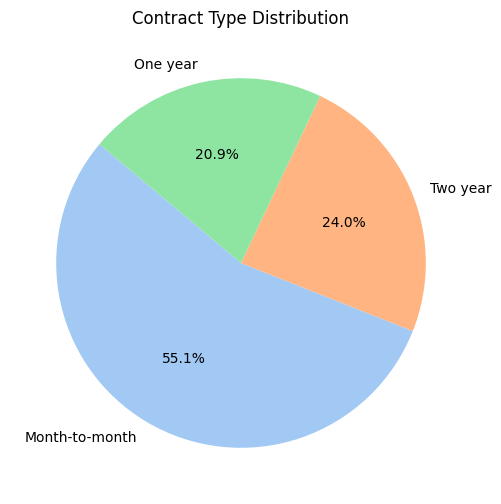

In [16]:
# Contract Type Pie Chart

plt.figure(figsize=(6, 6))
df['Contract'].value_counts().plot.pie(autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Contract Type Distribution')
plt.ylabel('')
plt.show()

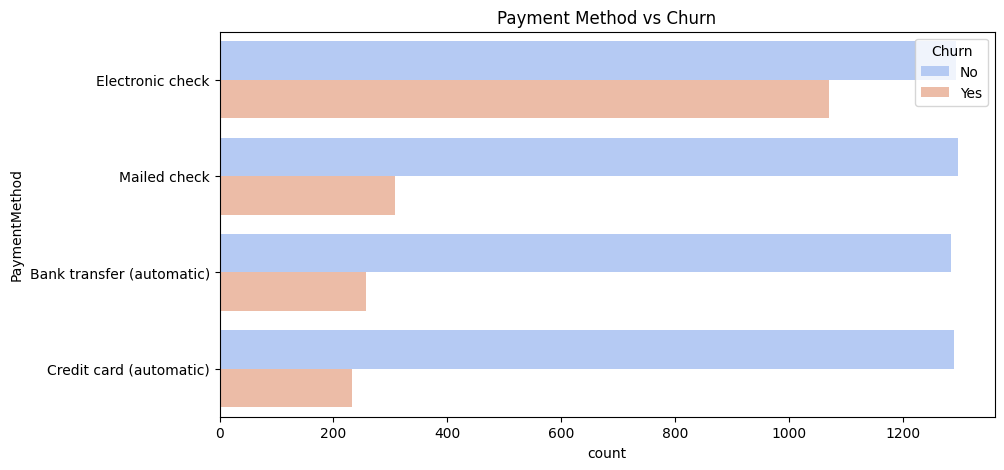

In [17]:
# Payment Method vs Churn

plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='PaymentMethod', hue='Churn', palette='coolwarm')
plt.title('Payment Method vs Churn')
plt.show()


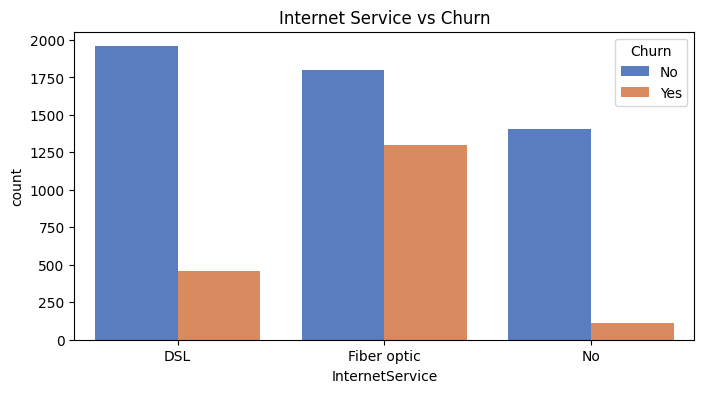

In [18]:
# Churn by InternetService

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='InternetService', hue='Churn', palette='muted')
plt.title('Internet Service vs Churn')
plt.show()

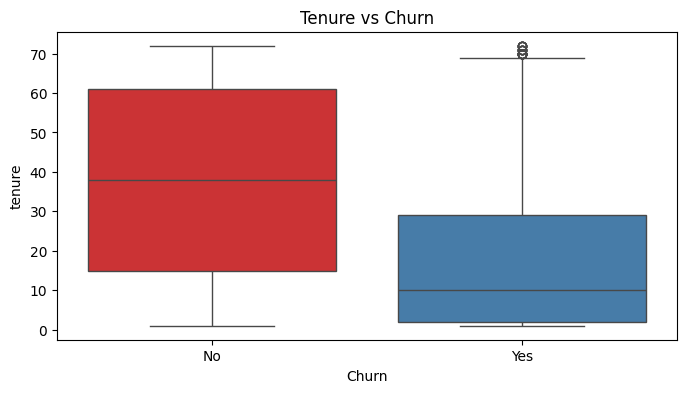

In [19]:
# Tenure vs Churn

plt.figure(figsize=(8, 4))
sns.boxplot(x='Churn', y='tenure', data=df, palette='Set1')
plt.title('Tenure vs Churn')
plt.show()

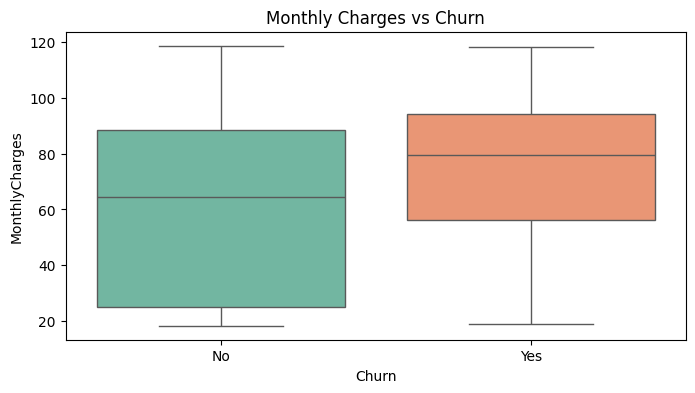

In [20]:
# Monthly Charges vs Churn

plt.figure(figsize=(8, 4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2')
plt.title('Monthly Charges vs Churn')
plt.show()

<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges'>

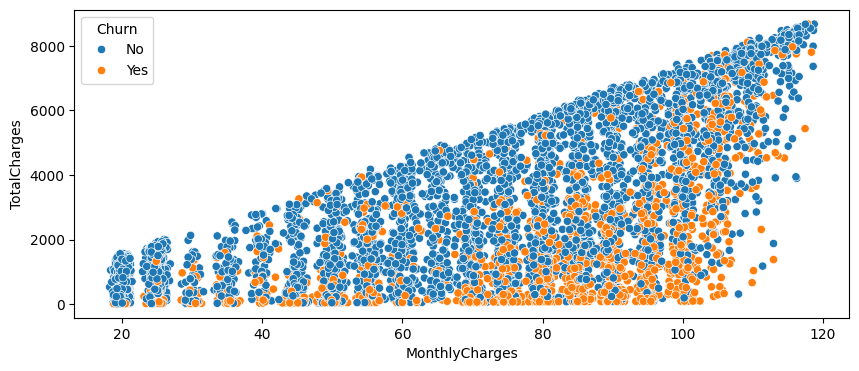

In [21]:
# Scatter plot of Monthly Charges versus Total Charges

plt.figure(figsize=(10,4))
sns.scatterplot(data=df, x='MonthlyCharges', y='TotalCharges', hue='Churn')

Feature Engineering

In [22]:
# Data reprocessing

df.drop('customerID', axis=1, inplace=True) # This column is unnecessary in the process
df.replace(['No internet service','No phone service'], 'No', inplace=True) # For convinience
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0}) # Mapping 'Churn' 'Yes/No' values to '1's and '0's

In [23]:
# One-Hot Encoding Nominal Features

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)


df_encoded.head(10)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,1,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,0,...,1,1,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
5,0,8,99.65,820.50,1,0,0,0,1,1,...,1,0,1,1,0,0,1,0,1,0
6,0,22,89.10,1949.40,0,1,0,1,1,1,...,0,0,1,0,0,0,1,1,0,0
7,0,10,29.75,301.90,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
8,0,28,104.80,3046.05,1,0,1,0,1,1,...,1,1,1,1,0,0,1,0,1,0
9,0,62,56.15,3487.95,0,1,0,1,1,0,...,0,0,0,0,1,0,0,0,0,0


In [24]:
# Scaling Numerical columns

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

In [25]:
# Creating New columns

df_encoded['AvgMonthlySpend'] = df_encoded['TotalCharges'] / (df_encoded['tenure'] + 1) # +1 for avoiding division by 0


def tenure_group(tenure):
    if tenure <= 12:
        return '0-1 year'
    elif tenure <= 24:
        return '1-2 years'
    elif tenure <= 48:
        return '2-4 years'
    elif tenure <= 60:
        return '4-5 years'
    else:
        return '5+ years'

df['tenure_group'] = df['tenure'].apply(tenure_group)
df_encoded = pd.get_dummies(df, columns=['tenure_group'], drop_first=True)
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

Modelling and Evaluating

In [26]:
# Splitting data into 'Train' and 'Test' phases

from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn', axis=1)  
y = df_encoded['Churn'] 

X = X.select_dtypes(include=[float, int])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Training set: (5625, 8), Test set: (1407, 8)



Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.90      0.85      1033
           1       0.60      0.41      0.49       374

    accuracy                           0.77      1407
   macro avg       0.71      0.66      0.67      1407
weighted avg       0.75      0.77      0.76      1407



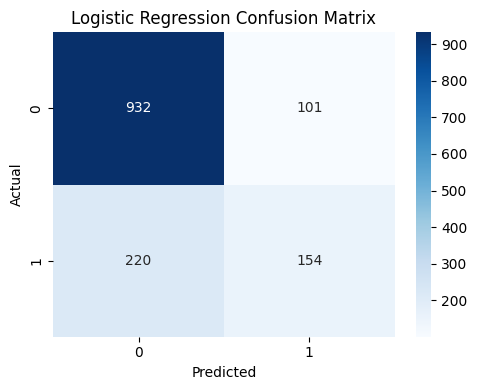


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.87      0.84      1033
           1       0.54      0.43      0.48       374

    accuracy                           0.75      1407
   macro avg       0.68      0.65      0.66      1407
weighted avg       0.74      0.75      0.74      1407



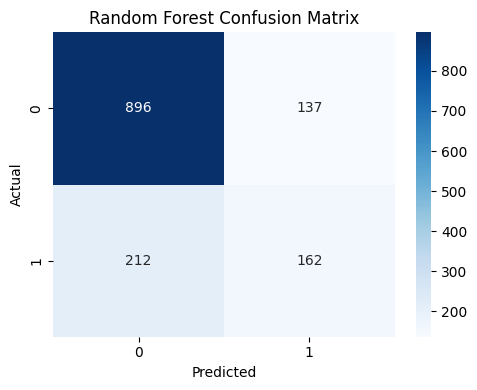


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85      1033
           1       0.59      0.44      0.50       374

    accuracy                           0.77      1407
   macro avg       0.70      0.66      0.68      1407
weighted avg       0.75      0.77      0.76      1407



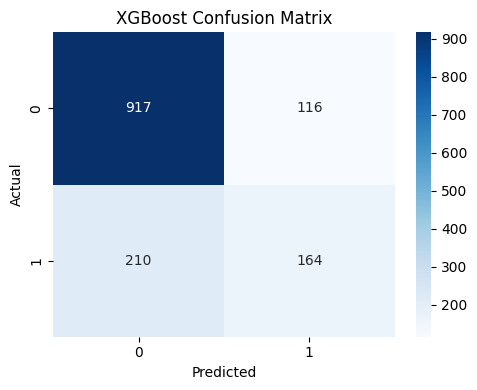


Model Performance Comparison:
                     Accuracy  Precision    Recall  F1 Score   ROC AUC
Logistic Regression  0.771855   0.603922  0.411765  0.489666  0.795097
Random Forest        0.751955   0.541806  0.433155  0.481426  0.768035
XGBoost              0.768301   0.585714  0.438503  0.501529  0.789880


<Figure size 1200x600 with 0 Axes>

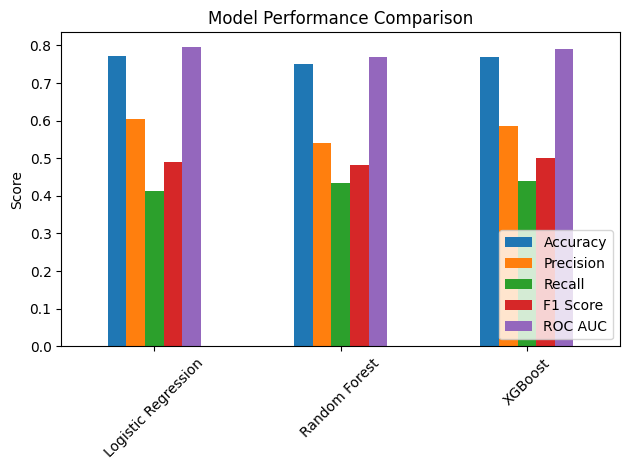

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC AUC': roc_auc
    }

    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(results).T
print("\nModel Performance Comparison:")
print(results_df)
plt.figure(figsize=(12, 6))
results_df.plot(kind='bar', rot=45)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

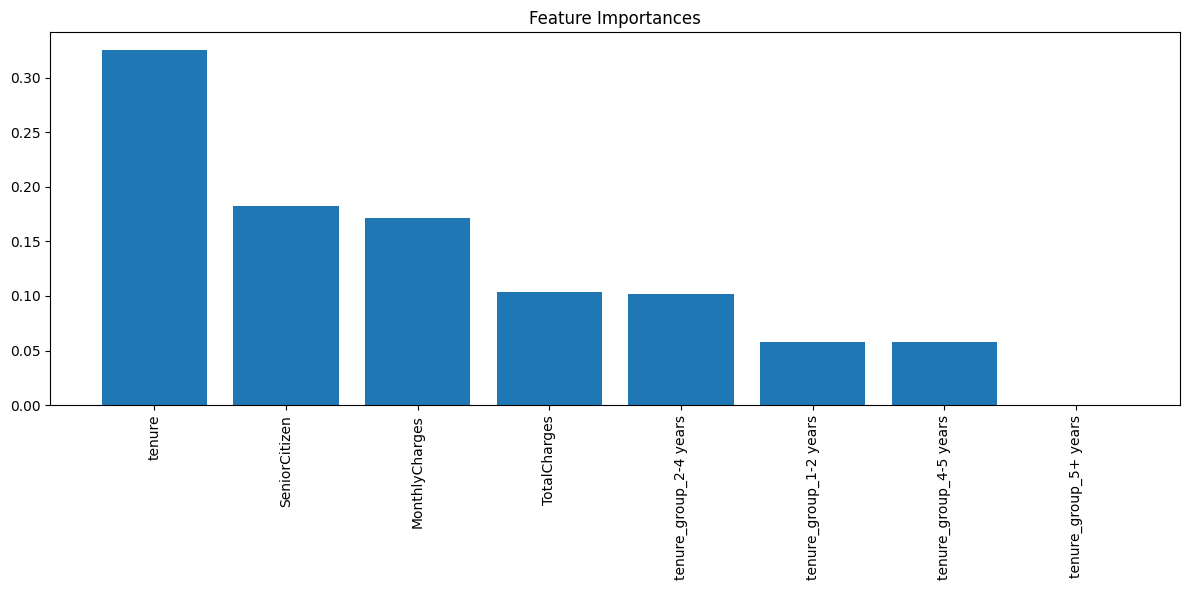

In [29]:
#Feature importance chart 
importances = model.feature_importances_
feature_names = X_train.columns

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importances")
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()


